# 12 — Exploratory security, care & appearance

**All analyses in this notebook are exploratory.** Topic sets are intentionally broader
than the frozen confirmatory constructs and **do not alter H1–H6 verdicts.**

Questions addressed:
- How does δ change as we broaden semantic definitions (strict → moderate → broad)?
- Which kinds of security promises distinguish high-rated romance?
- Presence vs conditional intensity of themes
- Danger × protection interaction
- Emotional security × appearance quadrants
- Fractional protection weights for mixed violence topics

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import exploratory_security as ex
from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh

ctx = nh.setup("12_exploratory_security_care_appearance")
cfg = ctx.cfg
GATE = nh.effect_gate(cfg)
exp_cfg = ex.load_exploratory_config(root / "configs/stage11/exploratory_security_care_appearance.yaml")
families = exp_cfg["families"]
promise_types = exp_cfg["promise_types"]
presence_threshold = float(exp_cfg.get("presence_threshold", 1e-5))

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance


In [2]:
frame = nh.load_refined_frame(cfg, "strict")
if "book_id" in frame.columns:
    frame = frame.set_index("book_id")
usable = frame[frame["analysable"].fillna(True)].copy() if "analysable" in frame.columns else frame.copy()
work = usable.reset_index()
if "book_id" not in work.columns and usable.index.name == "book_id":
    work["book_id"] = usable.index

shares = ex.topic_share_matrix(cfg)
master = pd.read_parquet(cfg.output_path("constructs_dir") / "master_annotations.parquet")

frac_cfg = exp_cfg.get("fractional_protection") or {}
frac_topics = frac_cfg.get("candidate_topics") or families["enacted_protection"].get("fractional_topics") or []
frac_weights = ex.build_fractional_protection_weights(
    cfg,
    candidate_topics=frac_topics,
    protection_codes=frac_cfg.get("protection_codes"),
)
weights_path = ctx.tables_dir / "exploratory_protection_weights.json"
ex.save_fractional_weights_json(frac_weights, weights_path)
print(f"Fractional protection weights saved → {weights_path}")
display(pd.Series(frac_weights, name="W_t_protection").sort_values(ascending=False))

Fractional protection weights saved → /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/exploratory_protection_weights.json


114   0.9474
87    0.9091
113   0.8636
122   0.2600
307   0.0588
Name: W_t_protection, dtype: float64

/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '
/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '


/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '
/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 7
  warnings.warn('covariance of constraints does not have full '


,family,level,feature,n_topics,cliffs_delta,ci_low,ci_high,verdict
0,emotional_security,strict,EXP_emotional_security_strict,10,0.0377,0.0164,0.0583,directional_only
1,emotional_security,moderate,EXP_emotional_security_moderate,29,0.0642,0.0412,0.0888,directional_only
2,emotional_security,broad,EXP_emotional_security_broad,45,0.1015,0.0787,0.1225,directional_only
3,protective_commitment,strict,EXP_protective_commitment_strict,0,0.0000,0.0000,0.0000,no reliable effect
4,protective_commitment,moderate,EXP_protective_commitment_moderate,5,0.1687,0.1487,0.1890,clears_gate
5,protective_commitment,broad,EXP_protective_commitment_broad,14,0.0003,-0.0205,0.0238,no reliable effect
6,enacted_protection,strict,EXP_enacted_protection_strict,1,0.1597,0.1410,0.1816,clears_gate
7,enacted_protection,moderate,EXP_enacted_protection_moderate,3,0.1795,0.1596,0.2016,clears_gate
8,enacted_protection,broad,EXP_enacted_protection_broad,10,0.1694,0.1472,0.1921,clears_gate
9,practical_care,strict,EXP_practical_care_strict,4,0.0573,0.0353,0.0770,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/strict_moderate_broad_trajectories.csv  (21 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/trajectory_plot.png


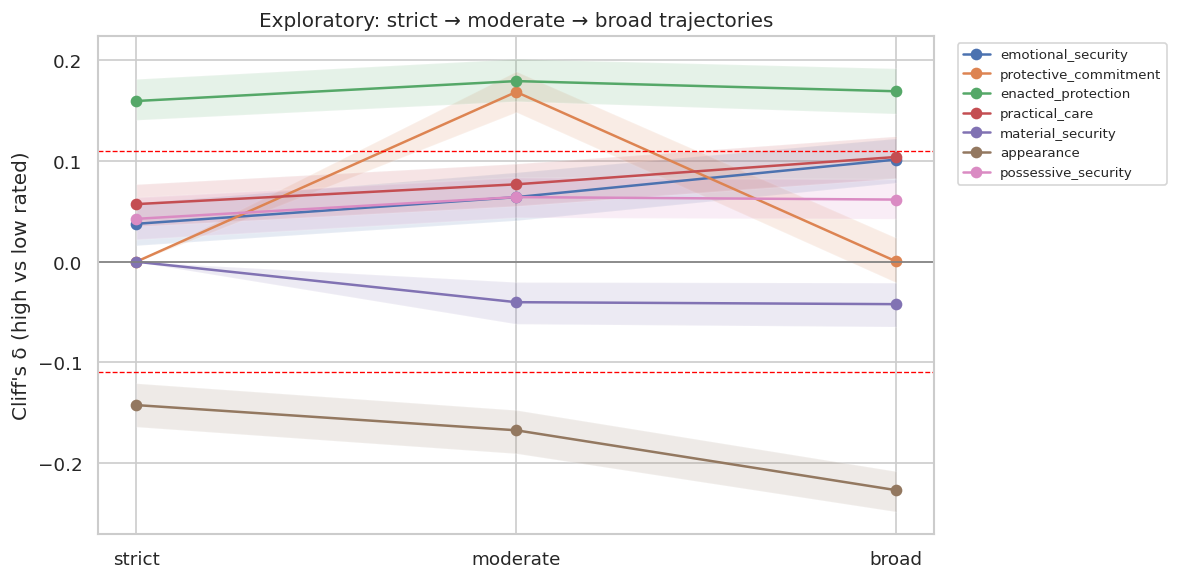

In [3]:
work_exp = ex.add_topic_set_columns(work, shares, families, fractional_weights=frac_weights)

def _test(df, feat, hyp, label=""):
    return nh.test_axis(
        df,
        feat,
        hyp,
        label=label,
        measurement_gate="viable",
        effect_gate=GATE,
        expected_sign=None,
        n_replicates=400,
        seed=42,
    )

trajectories = ex.trajectory_effects(work_exp, families, test_fn=_test)
display(trajectories.round(4))
ctx.save_table(trajectories, "strict_moderate_broad_trajectories")

# Trajectory plot
fig, ax = plt.subplots(figsize=(10, 5))
for family in trajectories["family"].unique():
    sub = trajectories[trajectories["family"] == family].set_index("level").reindex(["strict", "moderate", "broad"])
    ax.plot(sub.index, sub["cliffs_delta"], marker="o", label=family)
    ax.fill_between(
        range(len(sub)),
        sub["ci_low"],
        sub["ci_high"],
        alpha=0.15,
    )
ax.axhline(0, color="gray", lw=1)
ax.axhline(GATE, color="red", ls="--", lw=0.8)
ax.axhline(-GATE, color="red", ls="--", lw=0.8)
ax.set_ylabel("Cliff's δ (high vs low rated)")
ax.set_title("Exploratory: strict → moderate → broad trajectories")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
ctx.save_figure(fig, "trajectory_plot")
plt.show()

## Per-topic forest (broad enacted protection + emotional security)

In [4]:
forest_frames = []
for family, level in [("enacted_protection", "broad"), ("emotional_security", "broad")]:
    tids = families[family].get(level) or []
    forest = ex.topic_level_forest(shares, work, tids, master, test_fn=_test)
    forest.insert(0, "family", family)
    forest_frames.append(forest)
forest_all = pd.concat(forest_frames, ignore_index=True)
display(forest_all.sort_values("cliffs_delta", ascending=False).round(4))
ctx.save_table(forest_all, "topic_forest_broad_families")

,family,topic_id,topic_label,taxonomy_id,cliffs_delta,ci_low,ci_high,verdict
1,enacted_protection,78,Swearing War Before He Takes Her,7.2,0.1648,0.1420,0.1861,clears_gate
2,enacted_protection,87,Threatening Death As A Warning,7.2,0.1619,0.1409,0.1829,clears_gate
20,emotional_security,119,Offering to Keep Her Safe,4.6,0.1597,0.1410,0.1816,clears_gate
7,enacted_protection,119,Offering to Keep Her Safe,4.6,0.1597,0.1410,0.1816,clears_gate
29,emotional_security,238,Relaying A Message For Her,9.2,0.1480,0.1270,0.1702,clears_gate
43,emotional_security,372,Told to Keep Up Strength,4.6,0.1448,0.1225,0.1649,clears_gate
16,emotional_security,56,Promising Never to Hurt You,4.6,0.1377,0.1175,0.1574,clears_gate
27,emotional_security,193,Nurse Arranged After Hospital Release,4.6,0.1353,0.1143,0.1537,clears_gate
5,enacted_protection,114,Guns Aimed Across The Room,7.2,0.1306,0.1087,0.1539,clears_gate
6,enacted_protection,122,Wound Bleeding and Blood Loss,1.2,0.1288,0.1099,0.1509,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/topic_forest_broad_families.csv  (55 rows)


,promise_type,n_topics,cliffs_delta,ci_low,ci_high,verdict
5,protective_commitment,4,0.2098,0.1890,0.2321,clears_gate
6,enacted_external_protection,1,0.1597,0.1410,0.1816,clears_gate
1,non_harm_safety,1,0.1377,0.1175,0.1574,clears_gate
2,emotional_reassurance,4,0.1045,0.0823,0.1275,directional_only
0,trust_reliability,1,0.0934,0.0725,0.1128,directional_only
7,practical_care,5,0.0595,0.0368,0.0791,directional_only
9,possessive_protection,3,0.0426,0.0223,0.0641,directional_only
3,belonging_presence,3,-0.0144,-0.0334,0.0066,no reliable effect
4,long_term_partnership,3,-0.0193,-0.0422,0.0002,no reliable effect
8,material_provision,5,-0.0402,-0.0616,-0.0202,directional_only


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/promise_type_comparison.csv  (10 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/figures/promise_type_forest.png


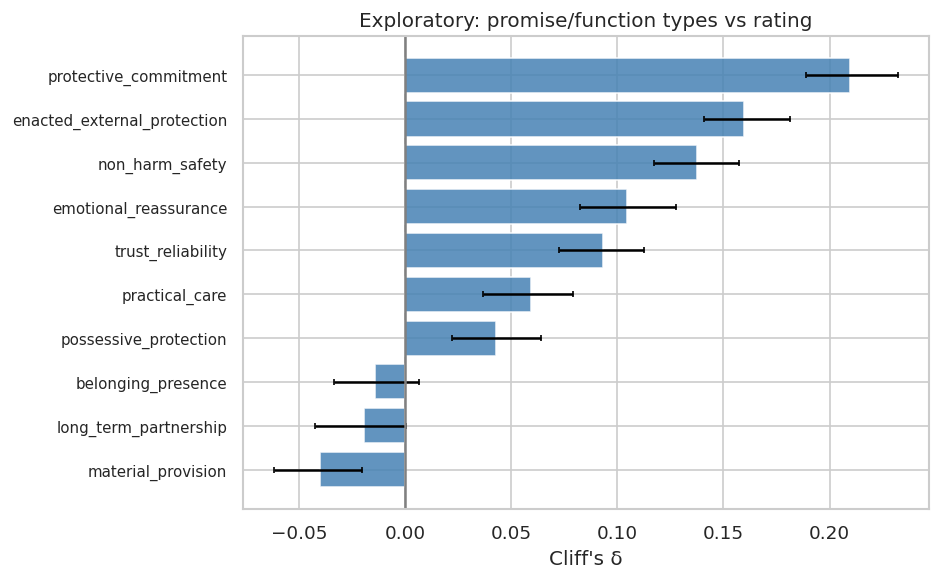

In [5]:
# Promise-type comparison table
promise_rows = []
for pname, tids in promise_types.items():
    col = f"EXP_promise_{pname}"
    tmp = work.copy()
    share = ex.topic_set_share(shares, tids)
    tmp[col] = ex._align_series_to_frame(share, tmp).values
    res = _test(tmp, col, "EXP", label=pname.replace("_", " "))
    promise_rows.append(
        {
            "promise_type": pname,
            "n_topics": len(tids),
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
promise_df = pd.DataFrame(promise_rows).sort_values("cliffs_delta", ascending=False)
display(promise_df.round(4))
ctx.save_table(promise_df, "promise_type_comparison")

fig, ax = plt.subplots(figsize=(8, 5))
plot_p = promise_df.dropna(subset=["cliffs_delta"]).sort_values("cliffs_delta")
y = np.arange(len(plot_p))
ax.barh(y, plot_p["cliffs_delta"], color="steelblue", alpha=0.85)
ax.errorbar(
    plot_p["cliffs_delta"],
    y,
    xerr=[
        plot_p["cliffs_delta"] - plot_p["ci_low"],
        plot_p["ci_high"] - plot_p["cliffs_delta"],
    ],
    fmt="none",
    ecolor="black",
    capsize=2,
)
ax.set_yticks(y)
ax.set_yticklabels(plot_p["promise_type"], fontsize=9)
ax.axvline(0, color="gray")
ax.set_xlabel("Cliff's δ")
ax.set_title("Exploratory: promise/function types vs rating")
plt.tight_layout()
ctx.save_figure(fig, "promise_type_forest")
plt.show()

## Presence vs conditional intensity

In [6]:
presence_rows = []
for family in families:
    for level in ("strict", "moderate", "broad"):
        col = f"EXP_{family}_{level}"
        if col not in work_exp.columns:
            continue
        s = work_exp.set_index("book_id")[col] if "book_id" in work_exp.columns else work_exp[col]
        stats = ex.presence_and_intensity(s, threshold=presence_threshold)
        presence_rows.append({"family": family, "level": level, **stats})
presence_df = pd.DataFrame(presence_rows)
display(presence_df.round(4))
ctx.save_table(presence_df, "presence_vs_intensity")

,family,level,prevalence,conditional_intensity,unconditional_mean
0,emotional_security,strict,0.9994,0.0243,0.0243
1,emotional_security,moderate,0.9997,0.0575,0.0574
2,emotional_security,broad,0.9997,0.1067,0.1067
3,protective_commitment,strict,0.0000,NaN,0.0000
4,protective_commitment,moderate,0.9977,0.0078,0.0078
5,protective_commitment,broad,0.9995,0.0397,0.0397
6,enacted_protection,strict,0.9862,0.0029,0.0029
7,enacted_protection,moderate,0.9951,0.0076,0.0075
8,enacted_protection,broad,0.9969,0.0095,0.0095
9,practical_care,strict,0.9980,0.0092,0.0092


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/presence_vs_intensity.csv  (21 rows)


## Danger × protection interaction

In [7]:
interaction_rows = []
for prot_col, label in [
    ("EXP_enacted_protection_strict", "strict t119 only"),
    ("EXP_enacted_protection_moderate", "moderate + fractional"),
    ("EXP_enacted_protection_broad", "broad enacted"),
]:
    if prot_col not in work_exp.columns:
        continue
    tmp = work_exp.copy()
    tmp[prot_col] = tmp[prot_col].fillna(0.0)
    inter = ex.danger_protection_interaction(
        tmp.set_index("book_id") if "book_id" in tmp.columns else tmp,
        protection_col=prot_col,
    )
    interaction_rows.append({"protection_index": label, **{f"{k}_beta": v.get("beta") for k, v in inter.items()}})
interaction_df = pd.DataFrame(interaction_rows)
display(interaction_df.round(4))
ctx.save_table(interaction_df, "danger_x_protection_interaction")

# 2×2 median split
for prot_col in ["EXP_enacted_protection_strict", "EXP_enacted_protection_moderate"]:
    if prot_col not in work_exp.columns or "RAX_external_danger_crisis" not in work_exp.columns:
        continue
    tmp = work_exp.copy()
    d_med = tmp["RAX_external_danger_crisis"].median()
    p_med = tmp[prot_col].median()
    tmp["_d_hi"] = tmp["RAX_external_danger_crisis"] >= d_med
    tmp["_p_hi"] = tmp[prot_col] >= p_med
    quad = (
        tmp.groupby(["_d_hi", "_p_hi"])["rating_shrunk"]
        .agg(["mean", "count"])
        .reset_index()
    )
    quad["protection_index"] = prot_col
    display(quad.round(4))

/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '
/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


/home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


,protection_index,_danger_beta,_prot_beta,_danger_x_prot_beta
0,strict t119 only,0.0078,6.9358,62.0667
1,moderate + fractional,0.3178,3.9712,-39.5063
2,broad enacted,0.3332,3.1528,-34.7736


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/danger_x_protection_interaction.csv  (3 rows)


,_d_hi,_p_hi,mean,count,protection_index
0,False,False,3.9007,4697,EXP_enacted_protection_strict
1,False,True,3.9289,3302,EXP_enacted_protection_strict
2,True,False,3.9077,3302,EXP_enacted_protection_strict
3,True,True,3.9486,4698,EXP_enacted_protection_strict


,_d_hi,_p_hi,mean,count,protection_index
0,False,False,3.8999,4959,EXP_enacted_protection_moderate
1,False,True,3.9327,3040,EXP_enacted_protection_moderate
2,True,False,3.9053,3040,EXP_enacted_protection_moderate
3,True,True,3.9479,4960,EXP_enacted_protection_moderate


## Emotional security × appearance quadrants

In [8]:
if "EXP_emotional_security_strict" in work_exp.columns and "EXP_appearance_strict" in work_exp.columns:
    quad_df = ex.quadrant_summary(
        work_exp.set_index("book_id") if "book_id" in work_exp.columns else work_exp,
        "EXP_emotional_security_strict",
        "EXP_appearance_strict",
    )
    display(quad_df.round(4))
    ctx.save_table(quad_df, "care_x_appearance_quadrants")

,_quad,rating_shrunk_mean,rating_shrunk_median,count
0,high_care_high_appearance,3.9131,3.9100,4275
1,high_care_low_appearance,3.9383,3.9245,3725
2,low_care_high_appearance,3.9056,3.9041,3725
3,low_care_low_appearance,3.9311,3.9174,4274


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/care_x_appearance_quadrants.csv  (4 rows)


## Fractional protection vs strict t119-only

In [9]:
compare_rows = []
for col in [
    "EXP_enacted_protection_strict",
    "EXP_enacted_protection_moderate",
    "RAX_external_protection",
]:
    if col not in work_exp.columns:
        continue
    res = _test(work_exp, col, "H4", label=col)
    compare_rows.append(
        {
            "index": col,
            "cliffs_delta": res.get("cliffs_delta"),
            "ci_low": res.get("ci_low"),
            "ci_high": res.get("ci_high"),
            "verdict": res.get("verdict"),
        }
    )
frac_compare = pd.DataFrame(compare_rows)
display(frac_compare.round(4))
ctx.save_table(frac_compare, "fractional_vs_strict_protection")
print("Exploratory notebook complete — results do not modify confirmatory H1–H6 verdicts.")

,index,cliffs_delta,ci_low,ci_high,verdict
0,EXP_enacted_protection_strict,0.1597,0.1410,0.1816,clears_gate
1,EXP_enacted_protection_moderate,0.1795,0.1596,0.2016,clears_gate
2,RAX_external_protection,0.1597,0.1410,0.1816,clears_gate


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/12_exploratory_security_care_appearance/tables/fractional_vs_strict_protection.csv  (3 rows)
Exploratory notebook complete — results do not modify confirmatory H1–H6 verdicts.
